Histogram A: [0.07 0.07 0.04 0.07 0.02 0.07 0.08 0.05 0.06 0.05 0.05 0.01 0.07 0.06
 0.06 0.05 0.04 0.08]
Histogram B: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


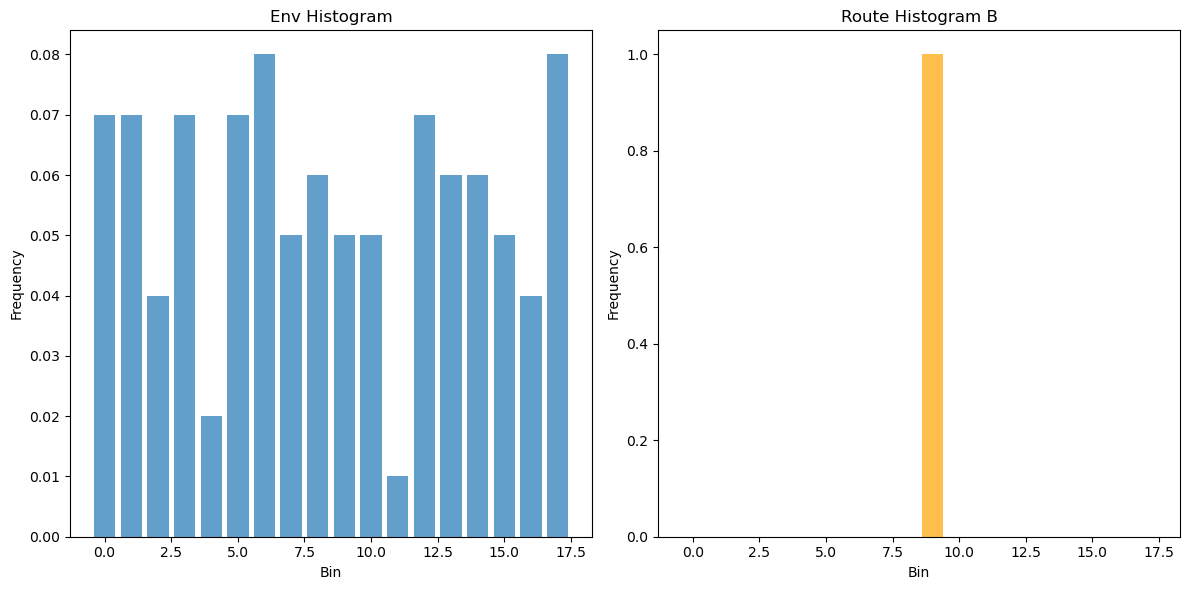

{'zero_lag': np.float64(0.05),
 'lag': np.int64(8),
 'strength': np.float64(0.08),
 'cross_correlation': array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.06, 0.05, 0.05,
        0.01, 0.07, 0.06, 0.06, 0.05, 0.04, 0.08])}

{'lag': np.int64(-1),
 'strength': np.float64(0.05111111111111111),
 'cross_correlation': array([-0.08      , -0.07111111, -0.06222222, -0.05333333, -0.04444444,
        -0.03555556, -0.02666667, -0.01777778,  0.05111111,  0.05      ,
         0.04111111, -0.00777778,  0.04333333,  0.02444444,  0.01555556,
        -0.00333333, -0.02222222,  0.00888889]),
 'cosine_distance': np.float64(0.7988705033227176),
 'euclidean_distance': 0.9807140255956371,
 'shifted_cosine_distance': np.float64(0.7586446039872612),
 'shifted_euclidean_distance': 0.9704638066409277}

{'zero_lag': np.float64(0.05),
 'lag': np.int64(8),
 'strength': np.float64(0.08),
 'cross_correlation': array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
        0.  , 0.  , 0.  , 0.  , 0.  , 0.06, 0.05, 0.05, 0.01, 0.07, 0.06,
        0.06, 0.05, 0.04, 0.08, 0.07, 0.07, 0.04, 0.07, 0.02, 0.07, 0.08,
        0.05, 0.  ])}

{'lag': np.int64(3),
 'strength': np.float64(0.05588235294117648),
 'cross_correlation': array([-0.08      , -0.07529412, -0.07058824, -0.06588235, -0.06117647,
        -0.05647059, -0.05176471, -0.04705882, -0.04235294, -0.03764706,
        -0.03294118, -0.02823529, -0.02352941, -0.01882353, -0.01411765,
        -0.00941176,  0.05529412,  0.05      ,  0.04529412,  0.00058824,
         0.05588235,  0.04117647,  0.03647059,  0.02176471,  0.00705882,
         0.04235294,  0.02764706,  0.02294118, -0.01176471,  0.01352941,
        -0.04117647,  0.00411765,  0.00941176, -0.02529412, -0.08      ]),
 'cosine_distance': np.float64(0.7988705033227176),
 'euclidean_distance': 0.9807140255956371,
 'shifted_cosine_distance': np.float64(0.7184187046518047),
 'shifted_euclidean_distance': 0.9601041610158764}

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, correlation_lags
from scipy.spatial.distance import cosine, euclidean
from scipy.stats import wasserstein_distance
import route_network_analysis as rna


def generate_histograms():
    num_bins = 36
    histogram_a = np.zeros(num_bins, dtype=float)
    histogram_b = np.zeros(num_bins, dtype=float)

    # Create a circularly symmetric histogram_a
    # Choose random indices in the first half, increment both index and its symmetric counterpart
    indices_a = np.random.choice(num_bins // 2, size=100, replace=True)
    for idx in indices_a:
        histogram_a[idx] += 1
        symmetric_idx = (idx + num_bins // 2) % num_bins
        histogram_a[symmetric_idx] += 1

    # Create a circularly symmetric histogram_b
    # Pick a single random index in the first half, set both index and its symmetric counterpart
    index_b = np.random.choice(num_bins // 2, size=1)
    histogram_b[index_b[0]] = 1
    symmetric_idx_b = (index_b[0] + num_bins // 2) % num_bins
    histogram_b[symmetric_idx_b] = 1

    return histogram_a, histogram_b, index_b

def plot_histograms(histogram_a, histogram_b):
    histogram_b = rna.alignment.fold_dist(histogram_b)
    histogram_a = rna.alignment.fold_dist(histogram_a)
    max_index = np.argmax(histogram_b)
    histogram_b = rna.alignment.roll_to_max(histogram_b, max_index)
    histogram_a = rna.alignment.roll_to_max(histogram_a, max_index)
    histogram_b = histogram_b / np.sum(histogram_b)
    histogram_a = histogram_a / np.sum(histogram_a)
    print("Histogram A:", histogram_a)
    print("Histogram B:", histogram_b)
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.bar(range(len(histogram_a)), histogram_a, alpha=0.7, label='Env Histogram')
    plt.title('Env Histogram')
    plt.xlabel('Bin')
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    plt.bar(range(len(histogram_b)), histogram_b, alpha=0.7, color='orange', label='Route Histogram B')
    plt.title('Route Histogram B')
    plt.xlabel('Bin')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

def print_metrics(env_dist, route_dist, index_b):


    strongest, closest = rna.alignment.find_optimal_correlation(env_dist,route_dist,)

    cosine_distance = cosine(histogram_a, histogram_b)
    euclidean_distance = euclidean(histogram_a, histogram_b)
    wasserstein_dist = wasserstein_distance(histogram_a, histogram_b)

    strongest_fft,closest_fft = rna.alignment.find_optimal_correlation(env_dist, route_dist,mode='full')

    display(strongest)
    display(closest)
    display(strongest_fft)
    display(closest_fft)
# Generate histograms, plot them, and print metrics
histogram_a, histogram_b, index_b = generate_histograms()
plot_histograms(histogram_a, histogram_b)
print_metrics(histogram_a, histogram_b, index_b)
